────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Функция        | Метод                | старт          | x*                     | f(x*)      | iter   | точек
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Квадр.(b=1)    | Флетчер-Ривс         | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
  Квадр.(b=1)    | Полак-Рибьер         | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
  Квадр.(b=1)    | Диксон               | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
  Квадр.(b=1)    | Дайян                | (3.00 , 3.00 ) | (0.00000  , 0.00000  ) | 0.000000   | 2      | 3
  Квадр.(b=1)    | Хестенс-Стифель      | (3.00 , 3.00 ) | (0.00001  , 0.00001  ) | 0.000000   | 2      | 3
────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Квадр.(b=10)   | Фл

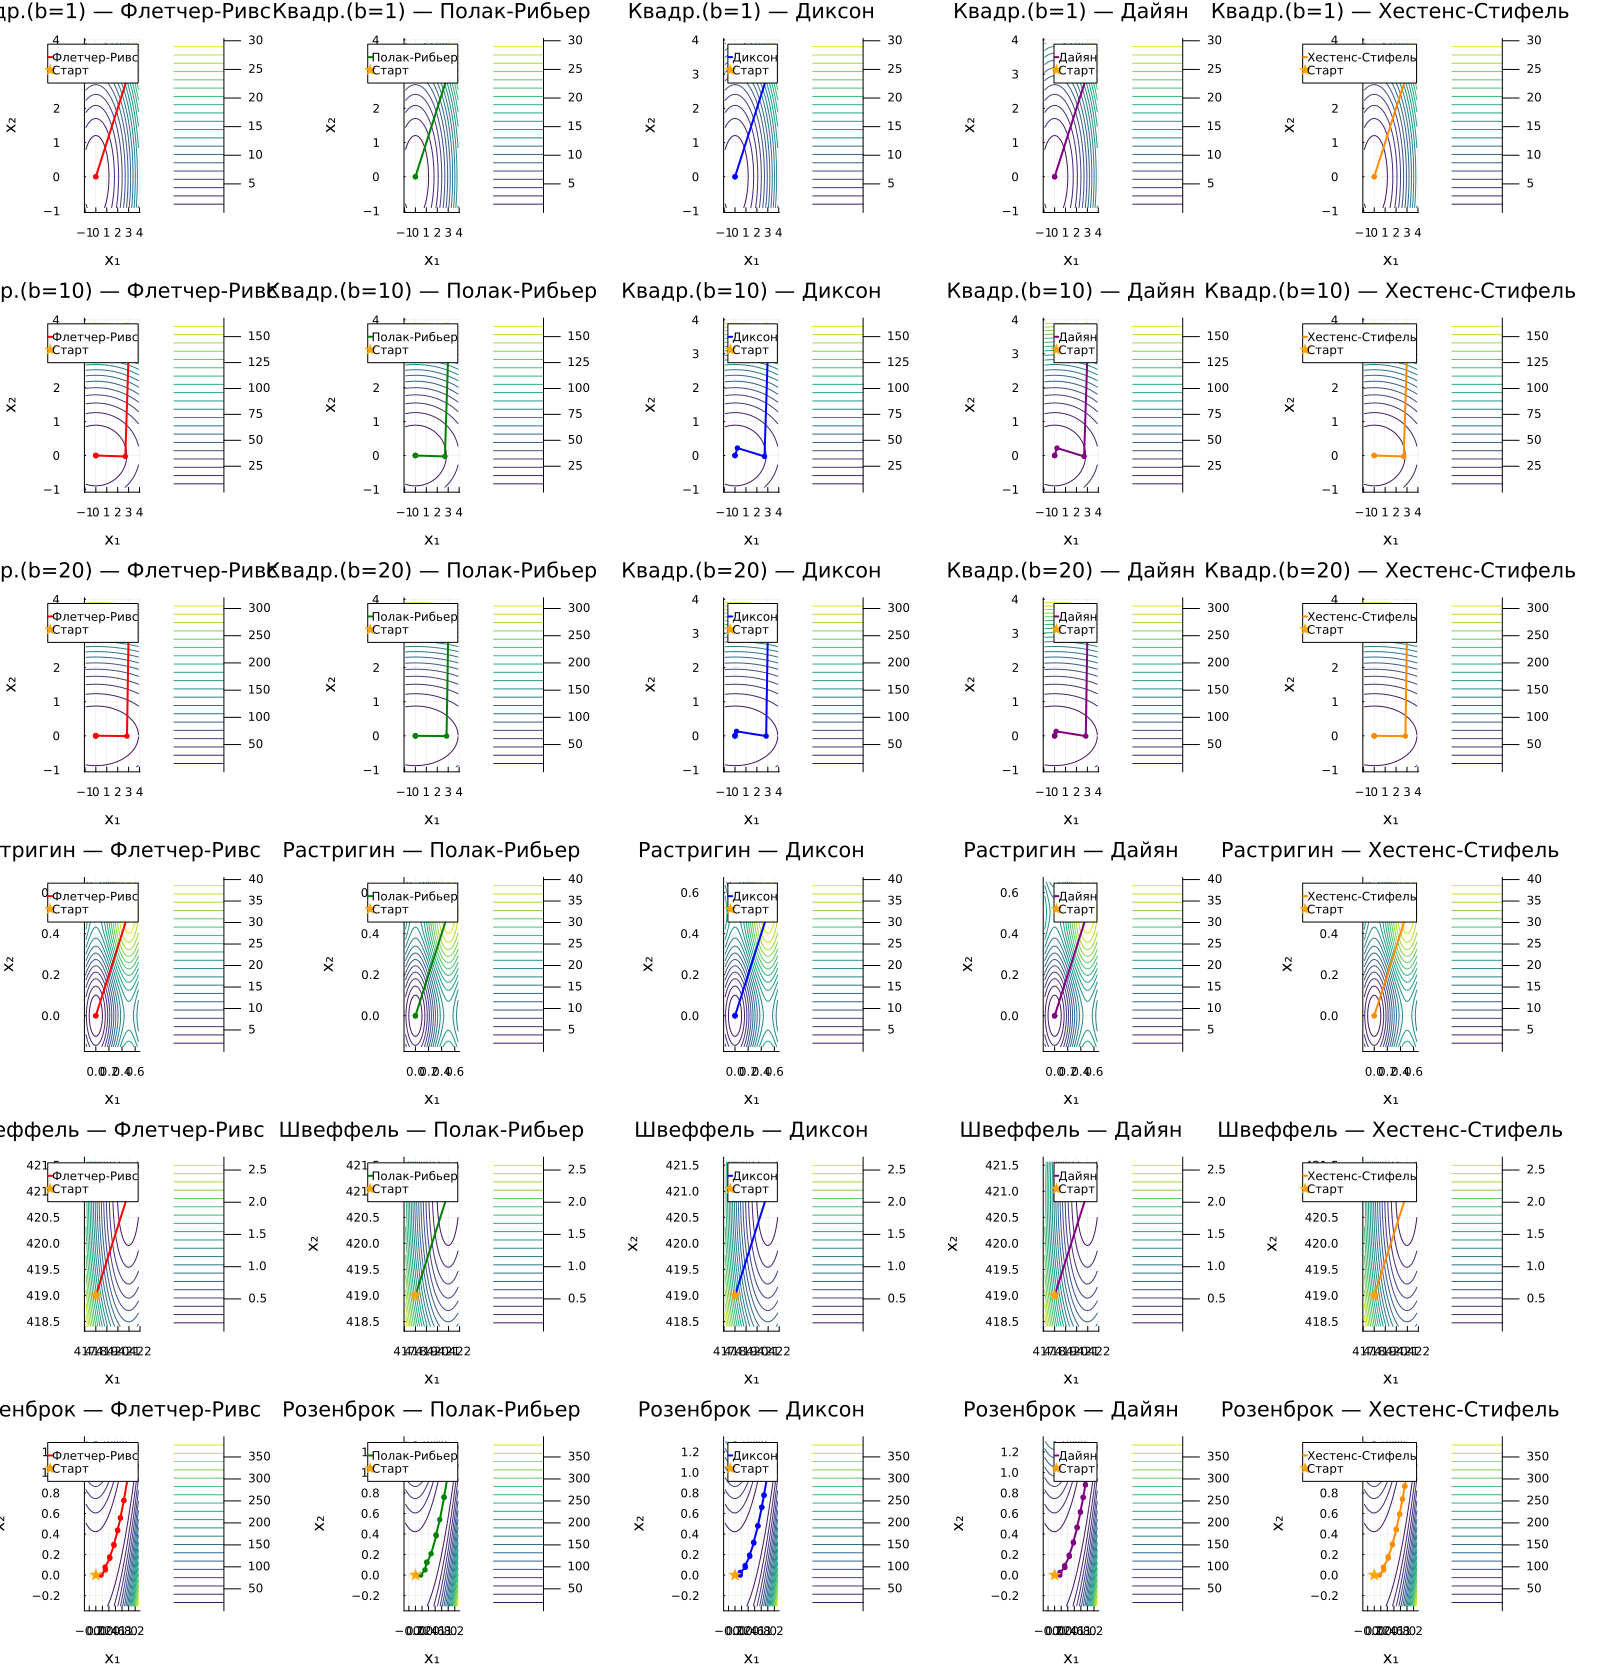

In [2]:
using LinearAlgebra
using Plots
using Printf


f_quad1((x, y)) = 1.0 * x^2 +  1.0 * y^2
f_quad2((x, y)) = 1.0 * x^2 + 10.0 * y^2
f_quad3((x, y)) = 1.0 * x^2 + 20.0 * y^2
f_rast((x, y); A=10.0)          = 2A + (x^2 - A*cos(2π*x)) + (y^2 - A*cos(2π*y))
f_schwef((x, y))                 = 418.9829*2 - (x*sin(sqrt(abs(x))) + y*sin(sqrt(abs(y))))
f_rosen((x, y); a=1.0, b=100.0) = (a - x)^2 + b*(y - x^2)^2


function sven(f, x0)
    h  = 0.01
    f0 = f(x0)
    f1 = f(x0 + h)

    if f1 > f0
        h  = -h
        f1 = f(x0 + h)
        if f1 > f0
            return (min(x0 - abs(h), x0 + abs(h)), max(x0 - abs(h), x0 + abs(h)))
        end
    end

    x_prev, x_curr = x0, x0 + h
    f_curr = f1

    for k in 1:100
        h2     = h * 2.0^k
        x_next = x0 + h2
        f_next = f(x_next)

        if f_next >= f_curr
            return (min(x_prev, x_next), max(x_prev, x_next))
        end

        x_prev = x_curr
        x_curr, f_curr = x_next, f_next
    end

    return (min(x_prev, x_curr), max(x_prev, x_curr))
end


function fib_search(f, a, b)
    eps = 1e-5

    if (b - a) <= eps
        return (a + b) / 2
    end

    F = [1, 1]
    while F[end] < (b - a) / eps
        push!(F, F[end] + F[end-1])
    end
    N = length(F)

    x1 = a + (F[N-2] / F[N]) * (b - a)
    x2 = a + (F[N-1] / F[N]) * (b - a)
    f1, f2 = f(x1), f(x2)

    for k in 1:(N - 3)
        if f1 > f2
            a  = x1; x1 = x2; f1 = f2
            x2 = a + (F[N-k-1] / F[N-k]) * (b - a)
            f2 = f(x2)
        else
            b  = x2; x2 = x1; f2 = f1
            x1 = a + (F[N-k-2] / F[N-k]) * (b - a)
            f1 = f(x1)
        end
    end

    return (a + b) / 2
end


function line_search(f, x, d)
    phi(a) = f(x .+ a .* d)
    a, b   = sven(phi, 0.0)
    a      = max(a, 0.0)
    b < a  && ((a, b) = (b, a))
    b      = max(b, a + 1e-8)
    return fib_search(phi, a, b)
end


function numgrad(f, x; h=1e-6)
    xv = collect(Float64, x)
    n  = length(xv)
    g  = zeros(Float64, n)
    ei = zeros(Float64, n)

    for i in 1:n
        fill!(ei, 0.0); ei[i] = 1.0
        g[i] = (f(xv .+ h .* ei) - f(xv .- h .* ei)) / (2h)
    end

    return g
end


function fletcher_reeves(f, x0; eps=1e-6, maxit=5000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    p  = -copy(g)

    for iter in 1:maxit
        norm(g) < eps && return x, xs

        alpha = line_search(f, x, p)
        xnew  = x .+ alpha .* p
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        gnew  = numgrad(f, xnew)
        denom = dot(g, g)
        beta  = denom < 1e-30 ? 0.0 : dot(gnew, gnew) / denom
        beta  = (iter % n == 0) ? 0.0 : beta

        p    = -gnew .+ beta .* p
        x, g = xnew, gnew
    end

    return xs[end], xs
end


function polak_ribiere(f, x0; eps=1e-6, maxit=5000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    p  = -copy(g)

    for iter in 1:maxit
        norm(g) < eps && return x, xs

        alpha = line_search(f, x, p)
        xnew  = x .+ alpha .* p
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        gnew  = numgrad(f, xnew)
        denom = dot(g, g)
        beta  = denom < 1e-30 ? 0.0 : dot(gnew, gnew .- g) / denom
        beta  = (iter % (n + 1) == 0 || beta <= 0.0) ? 0.0 : beta

        p    = -gnew .+ beta .* p
        x, g = xnew, gnew
    end

    return xs[end], xs
end


function dixon(f, x0; eps=1e-6, maxit=5000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    p  = -copy(g)

    alpha = line_search(f, x, p)
    xnew  = x .+ alpha .* p
    push!(xs, copy(xnew))

    x, g_prev, p_prev = xnew, g, p

    for iter in 2:maxit
        g = numgrad(f, x)
        norm(g) < eps && return x, xs

        denom = dot(p_prev, g_prev)
        beta  = abs(denom) < 1e-30 ? 0.0 : -dot(g, g) / denom
        beta  = (iter % n == 0) ? 0.0 : beta

        p     = -g .+ beta .* p_prev
        alpha = line_search(f, x, p)
        xnew  = x .+ alpha .* p
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        p_prev = p
        g_prev = g
        x      = xnew
    end

    return xs[end], xs
end


function dai_yuan(f, x0; eps=1e-6, maxit=5000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    p  = -copy(g)

    alpha = line_search(f, x, p)
    xnew  = x .+ alpha .* p
    push!(xs, copy(xnew))

    x, g_prev, p_prev = xnew, g, p

    for iter in 2:maxit
        g    = numgrad(f, x)
        norm(g) < eps && return x, xs

        dg    = g .- g_prev
        denom = dot(p_prev, dg)
        beta  = abs(denom) < 1e-30 ? 0.0 : dot(g, dg) / denom
        beta  = (iter % n == 0) ? 0.0 : beta

        p     = -g .+ beta .* p_prev
        alpha = line_search(f, x, p)
        xnew  = x .+ alpha .* p
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        p_prev = p
        g_prev = g
        x      = xnew
    end

    return xs[end], xs
end


function hestenes_stiefel(f, x0; eps=1e-6, maxit=5000)
    n  = length(x0)
    x  = collect(Float64, x0)
    xs = [copy(x)]
    g  = numgrad(f, x)
    p  = -copy(g)

    for iter in 1:maxit
        norm(g) < eps && return x, xs

        alpha = line_search(f, x, p)
        xnew  = x .+ alpha .* p
        push!(xs, copy(xnew))
        norm(xnew - x) < eps && return xnew, xs

        gnew  = numgrad(f, xnew)
        dg    = gnew .- g
        denom = dot(p, dg)
        beta  = abs(denom) < 1e-30 ? 0.0 :  dot(gnew, dg) / denom
        beta  = (iter % n == 0) ? 0.0 : beta

        p    = -gnew .+ beta .* p
        x, g = xnew, gnew
    end

    return xs[end], xs
end


function plot_path(f, hist, title_str, label, color; gridN=200, pad=0.3)
    xs = Float64[pt[1] for pt in hist]
    ys = Float64[pt[2] for pt in hist]

    dx = max(maximum(xs) - minimum(xs), 1e-6)
    dy = max(maximum(ys) - minimum(ys), 1e-6)

    xmin = minimum(xs) - pad*dx; xmax = maximum(xs) + pad*dx
    ymin = minimum(ys) - pad*dy; ymax = maximum(ys) + pad*dy

    xg = range(xmin, xmax; length=gridN)
    yg = range(ymin, ymax; length=gridN)
    Z  = [try f((xi, yi)) catch; f(xi, yi) end for yi in yg, xi in xg]

    p = contour(xg, yg, Z;
        xlabel="x₁", ylabel="x₂", title=title_str,
        legend=:topright, color=:viridis, levels=20)

    plot!(p, xs, ys; lw=2, label=label, color=color)

    scatter!(p, xs, ys; ms=3, label="", color=color, markerstrokewidth=0)

    scatter!(p, [xs[1]], [ys[1]];
        ms=7, shape=:star5, color=:orange, label="Старт", markerstrokewidth=0)

    return p
end


x0_q  = (3.0, 3.0)
x0_r  = (0.5, 0.5)
x0_s  = (418.0, 419.0)
x0_ro = (0.0, 0.0)

methods     = [fletcher_reeves, polak_ribiere, dixon, dai_yuan, hestenes_stiefel]
mnames      = ["Флетчер-Ривс", "Полак-Рибьер", "Диксон", "Дайян", "Хестенс-Стифель"]
mcolors     = [:red, :green, :blue, :purple, :darkorange]

functions   = [f_quad1,     f_quad2,      f_quad3,      f_rast,    f_schwef,   f_rosen  ]
fnames      = ["Квадр.(b=1)","Квадр.(b=10)","Квадр.(b=20)","Растригин","Швеффель","Розенброк"]
x0s         = [x0_q,        x0_q,         x0_q,         x0_r,      x0_s,       x0_ro    ]
maxits      = [5000,         5000,         5000,         5000,      5000,       5000     ]

all_results = Dict()
for (fi, fn, x0, mit) in zip(functions, fnames, x0s, maxits)
    all_results[fn] = []
    for mf in methods
        xm, h = mf(fi, x0; maxit=mit)
        push!(all_results[fn], (xm, h))
    end
end


sep = "─"^108
println(sep)
@printf("  %-14s | %-20s | %-14s | %-22s | %-10s | %-6s | %s\n",
        "Функция", "Метод", "старт", "x*", "f(x*)", "iter", "точек")
println(sep)

for (fi, fn, x0) in zip(functions, fnames, x0s)
    for (mname, (xm, h)) in zip(mnames, all_results[fn])
        fval  = try fi((xm[1], xm[2])) catch; fi(xm[1], xm[2]) end
        iters = length(h) - 1
        npts  = length(h)
        @printf("  %-14s | %-20s | (%-5.2f, %-5.2f) | (%-9.5f, %-9.5f) | %-10.6f | %-6d | %d\n",
                fn, mname, x0[1], x0[2], xm[1], xm[2], fval, iters, npts)
    end
    println(sep)
end


all_plots = []
for (fi, fn) in zip(functions, fnames)
    for (mname, mc, (xm, h)) in zip(mnames, mcolors, all_results[fn])
        push!(all_plots, plot_path(fi, h, "$fn — $mname", mname, mc))
    end
end

plot(all_plots...;
     layout=(length(functions), length(methods)),
     size=(length(methods)*320, length(functions)*280))